# Описание модели

В этом ноутбуке реализована модель для бинарной классификации изображений: `real / fake`.

Модель принимает RGB-изображение размером `256x256` и возвращает один logit.  
Вероятность класса `fake` считается через `sigmoid`.

---

## Архитектура модели

Используется ручная реализация EfficientNet-B3-подобной сверточной архитектуры.

Основной строительный блок модели — `MBConv`:

- 1x1 convolution для расширения каналов;
- depthwise convolution 3x3 или 5x5;
- BatchNorm;
- SiLU activation;
- Squeeze-and-Excitation;
- 1x1 convolution для проекции каналов;
- residual connection, если размеры совпадают;
- stochastic depth для регуляризации.

Схема модели:

    Входное изображение
    [B, 3, 256, 256]
            |
            v
    Conv Stem
    Conv2d: 3 -> 40
    BatchNorm2d
    SiLU
            |
            v
    MBConv Stage 1
    kernel = 3
    stride = 1
    channels: 40 -> 24
    blocks = 2
            |
            v
    MBConv Stage 2
    kernel = 3
    stride = 2
    channels: 24 -> 32
    blocks = 3
            |
            v
    MBConv Stage 3
    kernel = 5
    stride = 2
    channels: 32 -> 48
    blocks = 3
            |
            v
    MBConv Stage 4
    kernel = 3
    stride = 2
    channels: 48 -> 96
    blocks = 5
            |
            v
    MBConv Stage 5
    kernel = 5
    stride = 1
    channels: 96 -> 136
    blocks = 5
            |
            v
    MBConv Stage 6
    kernel = 5
    stride = 2
    channels: 136 -> 232
    blocks = 6
            |
            v
    MBConv Stage 7
    kernel = 3
    stride = 1
    channels: 232 -> 384
    blocks = 2
            |
            v
    Final Conv
    Conv2d: 384 -> 1536
    BatchNorm2d
    SiLU
            |
            v
    AdaptiveAvgPool2d(1, 1)
            |
            v
    Flatten
            |
            v
    Dropout(p=0.3)
            |
            v
    Linear: 1536 -> 1
            |
            v
    Output logit
    [B, 1]

Параметры EfficientNet-B3-конфигурации:

    width_mult = 1.2
    depth_mult = 1.4
    dropout = 0.3
    stochastic_depth_prob = 0.2
    num_classes = 1

---

## Аугментации

Для обучения используются аугментации, направленные на повышение устойчивости модели к изменению масштаба, качества изображения, шумам и локальным искажениям.

Train-аугментации:

    RandomResizedCrop 256x256
    scale = (0.70, 1.0)
    ratio = (0.90, 1.10)

    HorizontalFlip(p=0.5)

    ShiftScaleRotate
    shift_limit = 0.04
    scale_limit = 0.12
    rotate_limit = 8
    p = 0.30

    OneOf:
        Downscale
        ImageCompression quality 40-85
    p = 0.50

    OneOf:
        GaussianBlur
        MedianBlur
    p = 0.20

    RandomBrightnessContrast(p=0.30)
    RandomGamma(p=0.25)
    CLAHE(p=0.15)
    ToGray(p=0.03)

    OneOf:
        ISONoise
        MultiplicativeNoise
    p = 0.20

    CoarseDropout
    max_holes = 8
    max_height = 24
    max_width = 24
    fill_value = (124, 116, 104)
    p = 0.20

    Normalize ImageNet mean/std
    ToTensorV2

Validation/Test обработка:

    Resize 288x288
    CenterCrop 256x256
    Normalize ImageNet mean/std
    ToTensorV2

---

## Обучение

Для обучения используется `BCEWithLogitsLoss`, так как модель возвращает один logit.

Для компенсации дисбаланса классов используется `pos_weight`:

    weight_ratio = n_neg / n_pos
    pos_weight = min(sqrt(weight_ratio), 2.5)

Оптимизатор:

    AdamW
    learning rate = 2e-4
    weight decay = 1e-2
    betas = (0.9, 0.999)

Scheduler:

    OneCycleLR
    max_lr = 3e-4
    epochs = 80
    anneal_strategy = "cos"

Также применяется gradient clipping:

    max_norm = 1.0

---

## Инференс

Модель возвращает один logit для каждого изображения.

Вероятность класса `fake` считается так:

    probs = torch.sigmoid(logits)

Финальное предсказание получается сравнением вероятности с выбранным threshold:

    preds = (probs >= threshold)

Финальный submission сохраняется в формате:

    id,target_feature

In [ ]:
import glob
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Optional, Sequence
import math
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import clear_output
import torch.nn.functional as F
import seaborn as sns



In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [ ]:
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        label = self.df.iloc[idx]["label"]

        img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, label

In [ ]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = os.listdir(root_dir)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        path = os.path.join(self.root_dir, file_name)

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, file_name

# Обработка данных

In [ ]:
!pip install -U albumentations==1.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transforms_effb3 = A.Compose([
    A.RandomResizedCrop(
        height=256,
        width=256,
        scale=(0.70, 1.0),
        ratio=(0.90, 1.10),
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.04,
        scale_limit=0.12,
        rotate_limit=8,
        border_mode=0,
        p=0.30
    ),

    A.OneOf([
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=0, p=1.0),
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=3, p=1.0),
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=1, p=1.0),
        A.ImageCompression(quality_lower=40, quality_upper=85, p=1.0),
    ], p=0.50),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.20),

    A.RandomBrightnessContrast(p=0.30),
    A.RandomGamma(gamma_limit=(80, 120), p=0.25),
    A.CLAHE(clip_limit=2.0, p=0.15),

    A.ToGray(p=0.03),

    A.OneOf([
        A.ISONoise(p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.20),

    A.CoarseDropout(
        max_holes=8,
        max_height=24,
        max_width=24,
        min_holes=1,
        min_height=8,
        min_width=8,
        fill_value=(124, 116, 104),
        p=0.20
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

val_transforms_effb3 = A.Compose([
    A.Resize(288, 288),
    A.CenterCrop(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transforms_effb31 = A.Compose([
    A.RandomResizedCrop(
        height=256,
        width=256,
        scale=(0.85, 1.0),
        ratio=(0.95, 1.05),
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.06,
        rotate_limit=5,
        border_mode=0,
        p=0.20
    ),

    A.OneOf([
        A.ImageCompression(quality_lower=55, quality_upper=90, p=1.0),
        A.Downscale(scale_min=0.80, scale_max=0.95, interpolation=1, p=1.0),
        A.Downscale(scale_min=0.80, scale_max=0.95, interpolation=3, p=1.0),
    ], p=0.30),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 3), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.10),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.20
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_transforms_effb31 = A.Compose([
    A.Resize(288, 288),
    A.CenterCrop(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

test_transforms_effb31 = val_transforms_effb31

In [ ]:
labels_for_train = pd.read_csv("/content/drive/MyDrive/YAN/train_solution.csv", header=None)
labels_for_train.columns = ["id", "label"]
train_df, val_df = train_test_split(
    labels_for_train,
    test_size=0.2,
    stratify=labels_for_train["label"],
    random_state=42
)

In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
print(os.listdir("/content"))
print(len(os.listdir("/content/train_images")))

['.config', 'drive', 'train_images', 'sample_data']
50000


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/test_images.zip -d /content/

In [ ]:
train_dataset = TrainDataset(train_df, "/content/train_images", transform=train_transforms_effb3)
val_dataset   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_effb3)
test_dataset  = TestDataset("/content/test_images", transform=val_transforms_effb31)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

# Модель EfficientNet-B3

In [ ]:
import math
from dataclasses import dataclass
from functools import partial
from typing import Callable, List, Optional

import torch
import torch.nn as nn


def _make_divisible(v: float, divisor: int = 8, min_value: Optional[int] = None) -> int:
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


def stochastic_depth(x: torch.Tensor, p: float, training: bool) -> torch.Tensor:
    if p == 0.0 or not training:
        return x
    keep_prob = 1.0 - p
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor


class Conv2dNormActivation(nn.Sequential):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        groups: int = 1,
        norm_layer: Callable[..., nn.Module] = nn.BatchNorm2d,
        activation_layer: Optional[Callable[..., nn.Module]] = nn.SiLU,
    ) -> None:
        padding = (kernel_size - 1) // 2
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False,
            ),
            norm_layer(out_channels),
        ]
        if activation_layer is not None:
            layers.append(activation_layer(inplace=True))
        super().__init__(*layers)


class SqueezeExcitation(nn.Module):
    def __init__(self, input_channels: int, squeeze_channels: int) -> None:
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(input_channels, squeeze_channels, kernel_size=1)
        self.act1 = nn.SiLU(inplace=True)
        self.fc2 = nn.Conv2d(squeeze_channels, input_channels, kernel_size=1)
        self.act2 = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.avgpool(x)
        scale = self.fc1(scale)
        scale = self.act1(scale)
        scale = self.fc2(scale)
        scale = self.act2(scale)
        return x * scale


@dataclass
class MBConvConfig:
    expand_ratio: float
    kernel: int
    stride: int
    input_channels: int
    out_channels: int
    num_layers: int
    width_mult: float
    depth_mult: float

    def __post_init__(self) -> None:
        self.input_channels = self.adjust_channels(self.input_channels, self.width_mult)
        self.out_channels = self.adjust_channels(self.out_channels, self.width_mult)
        self.num_layers = self.adjust_depth(self.num_layers, self.depth_mult)

    @staticmethod
    def adjust_channels(channels: int, width_mult: float) -> int:
        return _make_divisible(channels * width_mult, 8)

    @staticmethod
    def adjust_depth(num_layers: int, depth_mult: float) -> int:
        return int(math.ceil(num_layers * depth_mult))


class MBConv(nn.Module):
    def __init__(
        self,
        cnf: MBConvConfig,
        stochastic_depth_prob: float,
        norm_layer: Callable[..., nn.Module],
        se_layer: Callable[..., nn.Module] = SqueezeExcitation,
    ) -> None:
        super().__init__()

        if cnf.stride not in (1, 2):
            raise ValueError(f"Illegal stride value: {cnf.stride}")

        self.use_res_connect = (cnf.stride == 1 and cnf.input_channels == cnf.out_channels)
        activation_layer = nn.SiLU
        expanded_channels = _make_divisible(cnf.input_channels * cnf.expand_ratio, 8)

        layers: List[nn.Module] = []

        if expanded_channels != cnf.input_channels:
            layers.append(
                Conv2dNormActivation(
                    in_channels=cnf.input_channels,
                    out_channels=expanded_channels,
                    kernel_size=1,
                    norm_layer=norm_layer,
                    activation_layer=activation_layer,
                )
            )

        layers.append(
            Conv2dNormActivation(
                in_channels=expanded_channels,
                out_channels=expanded_channels,
                kernel_size=cnf.kernel,
                stride=cnf.stride,
                groups=expanded_channels,
                norm_layer=norm_layer,
                activation_layer=activation_layer,
            )
        )

        squeeze_channels = max(1, _make_divisible(cnf.input_channels // 4, 8))
        layers.append(se_layer(expanded_channels, squeeze_channels))

        layers.append(
            Conv2dNormActivation(
                in_channels=expanded_channels,
                out_channels=cnf.out_channels,
                kernel_size=1,
                norm_layer=norm_layer,
                activation_layer=None,
            )
        )

        self.block = nn.Sequential(*layers)
        self.stochastic_depth_prob = stochastic_depth_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.block(x)
        if self.use_res_connect:
            out = stochastic_depth(out, self.stochastic_depth_prob, self.training)
            out = out + x
        return out


class EfficientNet(nn.Module):
    def __init__(
        self,
        inverted_residual_setting: List[MBConvConfig],
        dropout: float,
        stochastic_depth_prob: float = 0.2,
        num_classes: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        last_channel: Optional[int] = None,
    ) -> None:
        super().__init__()

        if not inverted_residual_setting:
            raise ValueError("inverted_residual_setting should not be empty")
        if not isinstance(inverted_residual_setting, list) or not all(
            isinstance(s, MBConvConfig) for s in inverted_residual_setting
        ):
            raise TypeError("inverted_residual_setting should be List[MBConvConfig]")

        if norm_layer is None:
            norm_layer = partial(nn.BatchNorm2d, eps=1e-3, momentum=0.1)

        layers: List[nn.Module] = []

        firstconv_output_channels = inverted_residual_setting[0].input_channels
        layers.append(
            Conv2dNormActivation(
                in_channels=3,
                out_channels=firstconv_output_channels,
                kernel_size=3,
                stride=2,
                norm_layer=norm_layer,
                activation_layer=nn.SiLU,
            )
        )

        total_stage_blocks = sum(cnf.num_layers for cnf in inverted_residual_setting)
        stage_block_id = 0

        for cnf in inverted_residual_setting:
            stage: List[nn.Module] = []
            for layer_id in range(cnf.num_layers):
                block_cnf = MBConvConfig(
                    expand_ratio=cnf.expand_ratio,
                    kernel=cnf.kernel,
                    stride=cnf.stride if layer_id == 0 else 1,
                    input_channels=cnf.input_channels if layer_id == 0 else cnf.out_channels,
                    out_channels=cnf.out_channels,
                    num_layers=1,
                    width_mult=1.0,
                    depth_mult=1.0,
                )
                sd_prob = stochastic_depth_prob * float(stage_block_id) / total_stage_blocks
                stage.append(MBConv(block_cnf, sd_prob, norm_layer))
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))

        lastconv_input_channels = inverted_residual_setting[-1].out_channels
        lastconv_output_channels = last_channel if last_channel is not None else 1280

        layers.append(
            Conv2dNormActivation(
                in_channels=lastconv_input_channels,
                out_channels=lastconv_output_channels,
                kernel_size=1,
                norm_layer=norm_layer,
                activation_layer=nn.SiLU,
            )
        )

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(lastconv_output_channels, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                if m.weight is not None:
                    nn.init.ones_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                bound = 1.0 / math.sqrt(m.in_features)
                nn.init.uniform_(m.weight, -bound, bound)
                if m.bias is not None:
                  nn.init.zeros_(m.bias)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)

    def forward_head(self, x: torch.Tensor) -> torch.Tensor:
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.forward_head(x)
        return x


def efficientnet_b3(num_classes: int = 1, stochastic_depth_prob: float = 0.2) -> EfficientNet:
    width_mult = 1.2
    depth_mult = 1.4

    inverted_residual_setting = [
        MBConvConfig(1, 3, 1, 32, 16, 1, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 16, 24, 2, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 24, 40, 2, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 40, 80, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 1, 80, 112, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 112, 192, 4, width_mult, depth_mult),
        MBConvConfig(6, 3, 1, 192, 320, 1, width_mult, depth_mult),
    ]

    last_channel = _make_divisible(1280 * width_mult, 8)  # 1536 для B3

    return EfficientNet(
        inverted_residual_setting=inverted_residual_setting,
        dropout=0.3,
        stochastic_depth_prob=stochastic_depth_prob,
        num_classes=num_classes,
        norm_layer=partial(nn.BatchNorm2d, eps=1e-3, momentum=0.1),
        last_channel=last_channel,
    )



# Функции для обучения, валидации, вывода графика, подсчета метрик

In [ ]:
sns.set(style='darkgrid')

def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    train_f1: list[float],
    valid_f1: list[float],
    title: str
):
    plt.figure(figsize=(16, 6))
    plt.title(title + ' loss')
    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + ' accuracy')
    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + ' F1')
    plt.plot(train_f1, label='Train F1')
    plt.plot(valid_f1, label='Valid F1')
    plt.legend()
    plt.show()

In [ ]:
def train(model: nn.Module, data_loader: DataLoader, optimizer, loss_fn, scheduler=None, threshold=0.25):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        output = model(x).view(-1)          # [B]
        loss = loss_fn(output, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1

In [ ]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, threshold=0.25):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        output = model(x).view(-1)
        loss = loss_fn(output, y)

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(model, dataloader, threshold=0.5):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X).view(-1)
            probs = torch.sigmoid(logits)
            predicted_classes = (probs >= threshold).long()

            all_preds.extend(predicted_classes.cpu().numpy())
            all_true.extend(y.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return acc, prec, rec, f1

In [ ]:
from IPython.display import clear_output
import os
import torch


from IPython.display import clear_output
import os
import torch

def fit(model, train_loader, valid_loader, test_loader, optimizer, loss_fn, scheduler, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history, valid_f1_history = [], []

    best_valid_f1 = float('-inf')

    save_dir = "/content/drive/MyDrive/YAN"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_accuracy, train_prec, train_rec, train_f1 = train(
            model, train_loader, optimizer, loss_fn, scheduler
        )
        valid_loss, valid_accuracy, valid_prec, valid_rec, valid_f1 = evaluate(
            model, valid_loader, loss_fn
        )

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        train_f1_history.append(train_f1)
        valid_f1_history.append(valid_f1)

        # сохраняем лучшую модель по F1
        save_path = os.path.join(save_dir, f"Effic{epoch+1}_{valid_f1:.4f}_loss{valid_loss:.4f}.pth")
        torch.save(model.state_dict(), save_path)
        if valid_f1 > best_valid_f1:
          best_valid_f1 = valid_f1


        clear_output()
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            train_f1_history, valid_f1_history,
            title
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train loss: {train_loss:.4f} | Val loss: {valid_loss:.4f}")
        print(f"Train acc:  {train_accuracy:.4f} | Val acc:  {valid_accuracy:.4f}")
        print(f"Train F1:   {train_f1:.4f} | Val F1:   {valid_f1:.4f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f}")

# Загрузка модели

In [ ]:
model = efficientnet_b3(num_classes=1)
model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 16, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (fc2): Conv2d(16, 40, kernel_size=(1, 1), stride=(1, 1))
            (act2): Sigmoid()
          )
          (2): Conv2dNormActivation(
           

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model, input_size=(2, 3, 256, 256))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [2, 1]                    --
├─Sequential: 1-1                                       [2, 1536, 8, 8]           --
│    └─Conv2dNormActivation: 2-1                        [2, 40, 128, 128]         --
│    │    └─Conv2d: 3-1                                 [2, 40, 128, 128]         1,080
│    │    └─BatchNorm2d: 3-2                            [2, 40, 128, 128]         80
│    │    └─SiLU: 3-3                                   [2, 40, 128, 128]         --
│    └─Sequential: 2-2                                  [2, 24, 128, 128]         --
│    │    └─MBConv: 3-4                                 [2, 24, 128, 128]         2,784
│    │    └─MBConv: 3-5                                 [2, 24, 128, 128]         1,304
│    └─Sequential: 2-3                                  [2, 32, 64, 64]           --
│    │    └─MBConv: 3-6                            

# Лосы, санитайзеры

In [ ]:
n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos
n_neg / n_pos

np.float64(4.882352941176471)

In [ ]:
import math
import torch
import torch.nn as nn

num_epochs = 80


n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos

weight_ratio = n_neg / n_pos
smoothed_weight = min(math.sqrt(weight_ratio), 2.5)

pos_weight = torch.tensor([smoothed_weight], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-2,
    betas=(0.9, 0.999)
)


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.08,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=1000.0
)

# Обучение модели

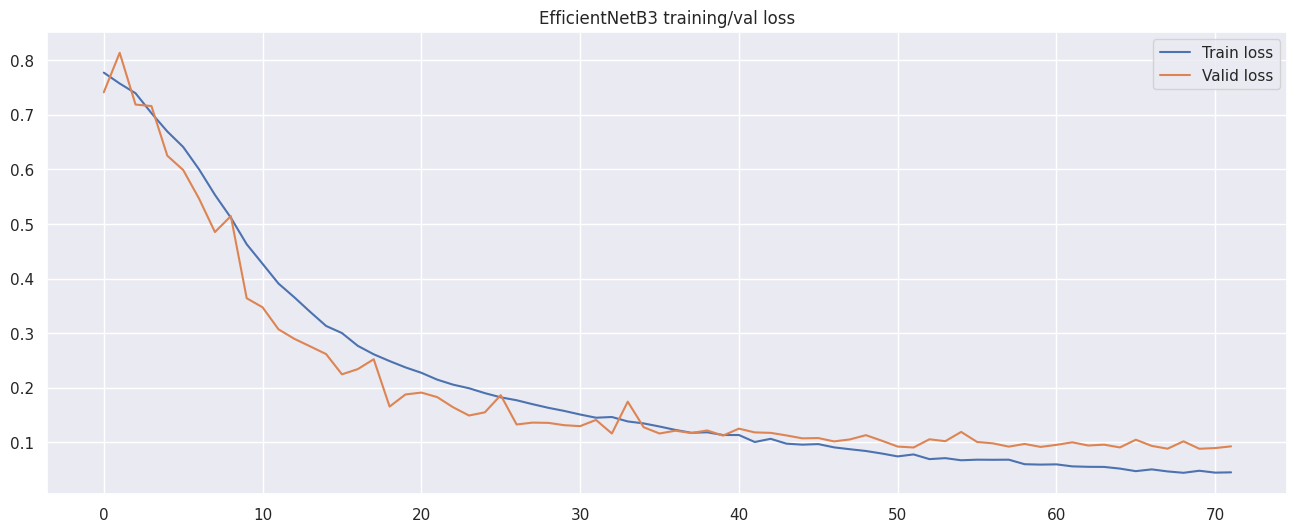

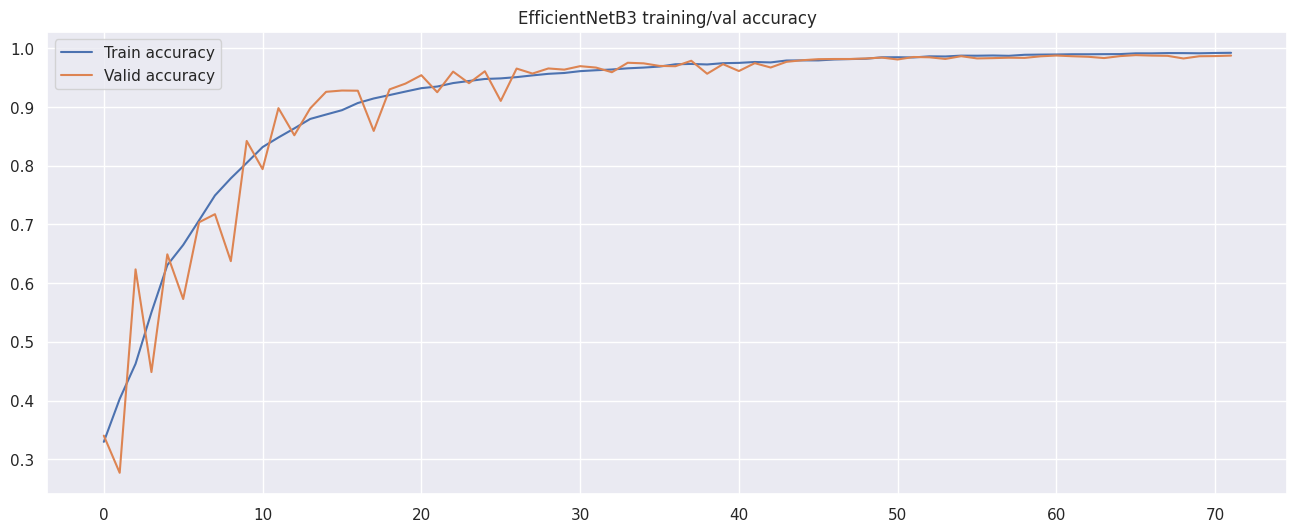

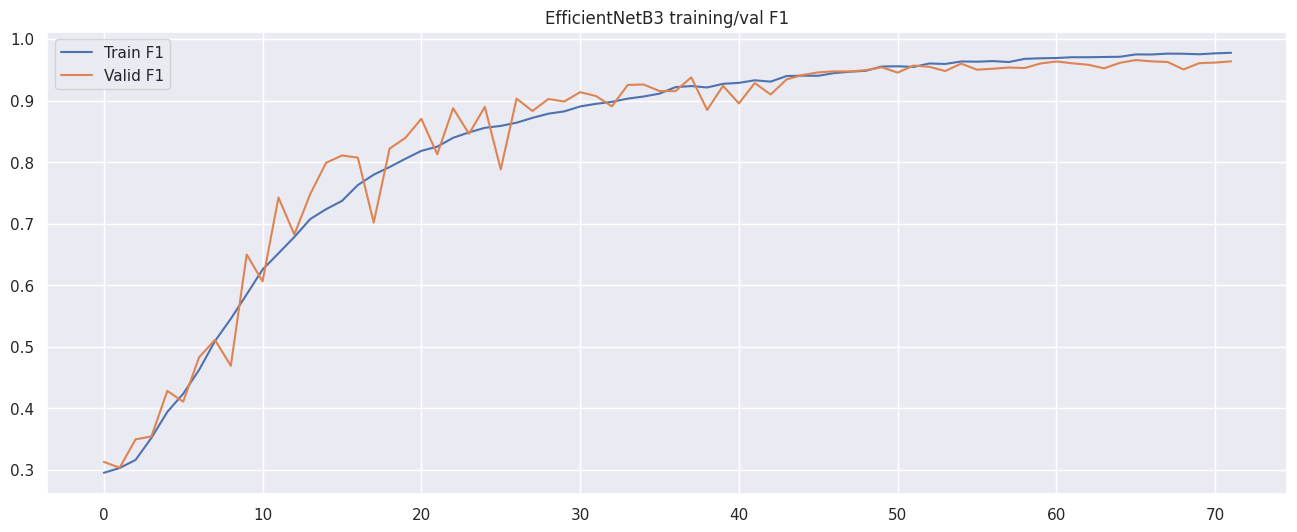

Epoch 72/80
Train loss: 0.0446 | Val loss: 0.0922
Train acc:  0.9923 | Val acc:  0.9876
Train F1:   0.9775 | Val F1:   0.9636
Best Val F1 so far: 0.9658


  2%|▏         | 25/1250 [00:12<10:01,  2.04it/s]


KeyboardInterrupt: 

In [ ]:
fit(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    scheduler,
    num_epochs,
    title="EfficientNetB3 training/val"
)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x).view(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_true.extend(y.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

print("probs min/max/mean:", all_probs.min(), all_probs.max(), all_probs.mean())
print("percentiles:", np.percentile(all_probs, [1, 5, 25, 50, 75, 95, 99]))

for thr in [0.1, 0.2, 0.3, 0.4, 0.5]:
    preds = (all_probs >= thr).astype(int)
    print("thr", thr, "f1", f1_score(all_true, preds, zero_division=0))
    print(confusion_matrix(all_true, preds))

probs min/max/mean: 1.2423316e-33 0.4954334 0.2982059
percentiles: [0.18744911 0.21569308 0.26385915 0.30371413 0.33970888 0.36467167
 0.3737762 ]
thr 0.1 f1 0.29162730785744956
[[  53 8247]
 [   2 1698]]
thr 0.2 f1 0.29294598590936766
[[ 187 8113]
 [  16 1684]]
thr 0.3 f1 0.30923983330938354
[[4117 4183]
 [ 624 1076]]
thr 0.4 f1 0.00234192037470726
[[8294    6]
 [1698    2]]
thr 0.5 f1 0.0
[[8300    0]
 [1700    0]]


# Дообучение с EMA

In [ ]:
import copy
import math
import os
import torch
import torch.nn as nn

class ModelEMA:
    def __init__(self, model, decay=0.9997, device=None):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        self.device = device

        for p in self.ema.parameters():
            p.requires_grad_(False)

        if self.device is not None:
            self.ema.to(self.device)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if not v.dtype.is_floating_point:
                v.copy_(msd[k])
            else:
                model_v = msd[k].detach()
                if self.device is not None:
                    model_v = model_v.to(self.device)
                v.copy_(v * self.decay + (1.0 - self.decay) * model_v)

    @torch.no_grad()
    def set(self, model):
        self.ema.load_state_dict(copy.deepcopy(model.state_dict()))

In [ ]:
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_one_epoch_ema(model, ema, data_loader, optimizer, loss_fn, scheduler=None, threshold=0.25):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        logits = model(x).view(-1)
        loss = loss_fn(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if ema is not None:
            ema.update(model)

        if scheduler is not None:
            scheduler.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1


@torch.inference_mode()
def evaluate_model(model_for_eval, data_loader, loss_fn, threshold=0.25):
    model_for_eval.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        logits = model_for_eval(x).view(-1)
        loss = loss_fn(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1

In [ ]:
from IPython.display import clear_output

def fit_ema(model, ema, train_loader, valid_loader, optimizer, loss_fn, scheduler, num_epochs, title, threshold=0.25):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history, valid_f1_history = [], []

    best_valid_f1 = float('-inf')
    best_path = None

    save_dir = "/content/drive/MyDrive/YAN"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_accuracy, train_prec, train_rec, train_f1 = train_one_epoch_ema(
            model=model,
            ema=ema,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scheduler=scheduler,
            threshold=threshold
        )

        valid_loss, valid_accuracy, valid_prec, valid_rec, valid_f1 = evaluate_model(
            model_for_eval=ema.ema if ema is not None else model,
            data_loader=valid_loader,
            loss_fn=loss_fn,
            threshold=threshold
        )

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        train_f1_history.append(train_f1)
        valid_f1_history.append(valid_f1)

        save_path = os.path.join(
            save_dir,
            f"EfficB3_EMA_ep{epoch+1}_{valid_f1:.4f}_loss{valid_loss:.4f}.pth"
        )

        ckpt = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema.ema.state_dict() if ema is not None else None,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "best_f1": valid_f1,
            "threshold": threshold,
        }

        torch.save(ckpt, save_path)

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            best_path = os.path.join(save_dir, "EfficB3_EMA_best.pth")
            torch.save(ckpt, best_path)

        clear_output()
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            train_f1_history, valid_f1_history,
            title
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train loss: {train_loss:.4f} | Val loss: {valid_loss:.4f}")
        print(f"Train acc:  {train_accuracy:.4f} | Val acc:  {valid_accuracy:.4f}")
        print(f"Train F1:   {train_f1:.4f} | Val F1 EMA: {valid_f1:.4f}")
        print(f"Best Val F1 EMA so far: {best_valid_f1:.4f}")
        print(f"Last ckpt: {save_path}")
        print(f"Best ckpt: {best_path}")

    return best_path

In [ ]:
model_ema_ft = efficientnet_b3(num_classes=1)
model_ema_ft.to(device)


base_ckpt_path = "/content/drive/MyDrive/YAN/Effic66_0.9658_loss0.1044.pth"
state = torch.load(base_ckpt_path, map_location=device)

if isinstance(state, dict) and "model_state_dict" not in state and "state_dict" not in state:
    model_ema_ft.load_state_dict(state)
elif "model_state_dict" in state:
    model_ema_ft.load_state_dict(state["model_state_dict"])
elif "state_dict" in state:
    model_ema_ft.load_state_dict(state["state_dict"])
else:
    model_ema_ft.load_state_dict(state)

print("Base checkpoint loaded:", base_ckpt_path)

Base checkpoint loaded: /content/drive/MyDrive/YAN/Effic66_0.9658_loss0.1044.pth


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

@torch.inference_mode()
def collect_probs_targets(model_for_eval, data_loader):
    model_for_eval.eval()
    all_probs = []
    all_true = []

    for x, y in data_loader:
        x = x.to(device)
        logits = model_for_eval(x).view(-1)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_true.extend(y.numpy())

    return np.array(all_probs), np.array(all_true)


def find_best_threshold_from_probs(probs, targets, t_min=0.05, t_max=0.95, step=0.0005):
    best_thr = 0.5
    best_f1 = -1.0

    for t in np.arange(t_min, t_max, step):
        preds = (probs >= t).astype(int)
        f1 = f1_score(targets, preds, average='binary', zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(t)

    return best_thr, best_f1

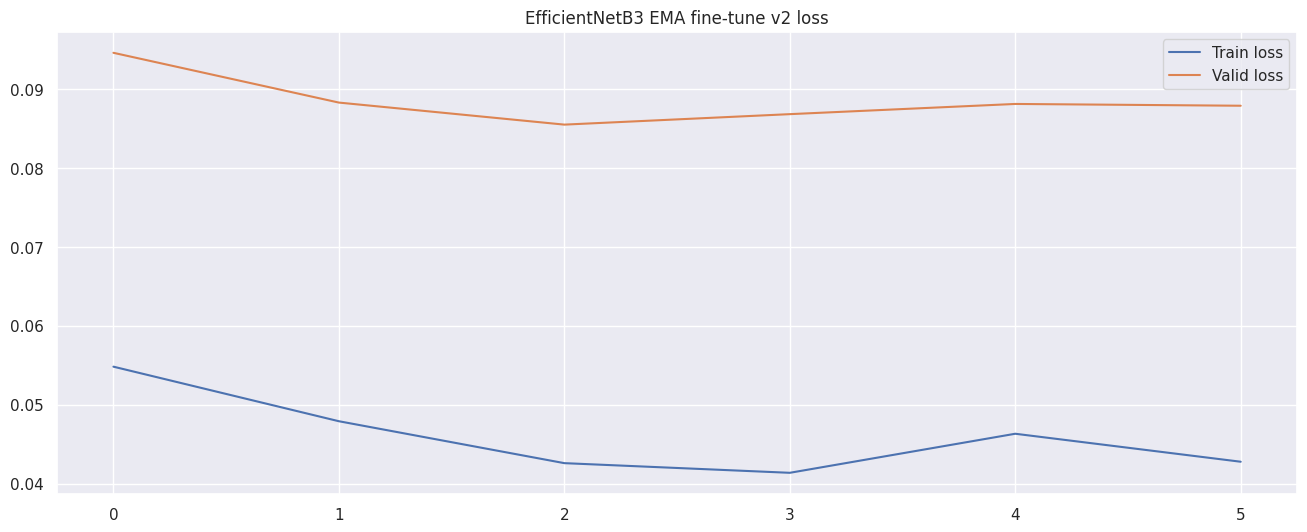

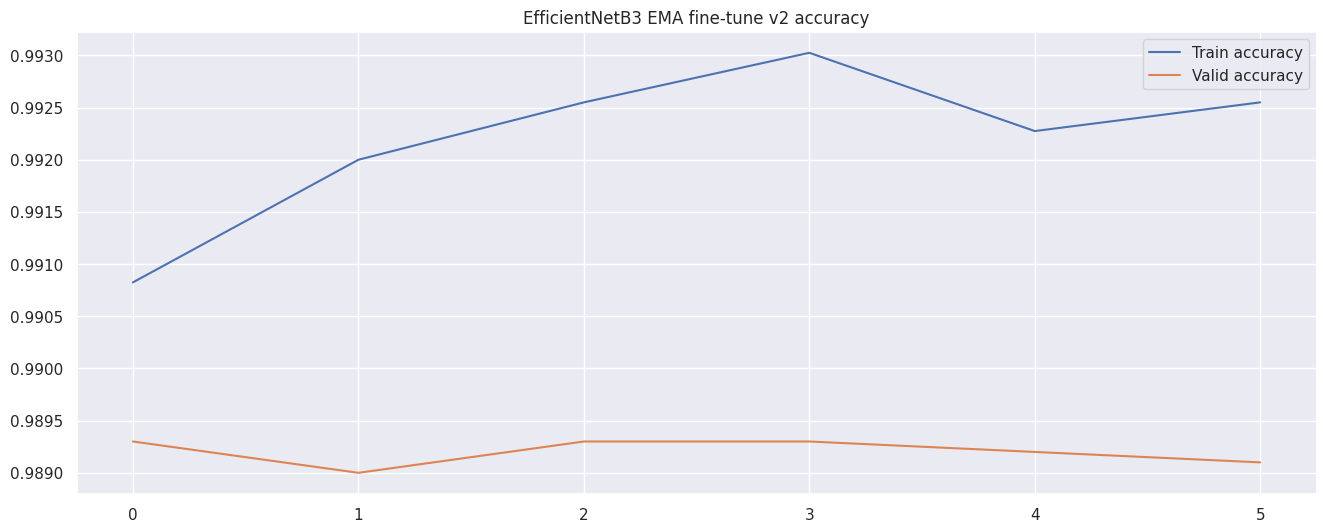

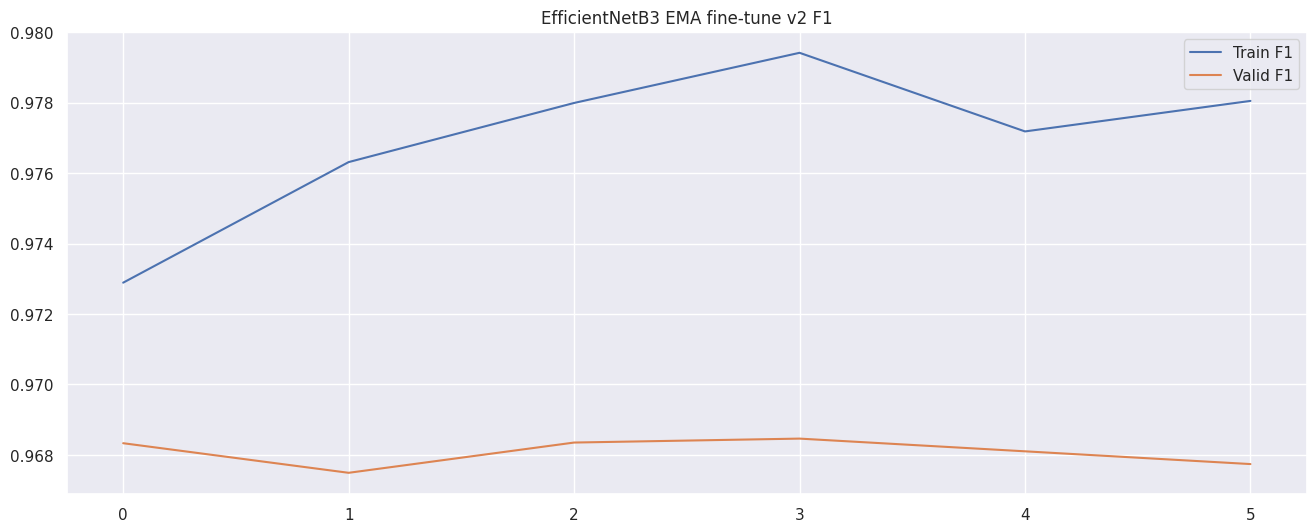

Epoch 6/6
Train loss: 0.0428 | Val loss: 0.0879
Train acc:  0.9926 | Val acc(best thr): 0.9891
Train F1:   0.9780 | Val F1 EMA(best thr): 0.9677
Best threshold this epoch: 0.9365
Current LR: 0.00000250
Best Val F1 EMA so far: 0.9685
Last ckpt: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_ep6_f10.9677_thr0.9365.pth
Best ckpt: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth
DONE. Best EMA checkpoint: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth


In [ ]:
ema_decay = 0.999
ema_model = ModelEMA(model_ema_ft, decay=ema_decay, device=device)
ema_model.set(model_ema_ft)

from IPython.display import clear_output

def fit_ema_v2(model, ema, train_loader, valid_loader, optimizer, loss_fn, scheduler, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history, valid_f1_history = [], []
    best_thr_history = []

    best_valid_f1 = float('-inf')
    best_path = None

    save_dir = "/content/drive/MyDrive/YAN"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        # ---- train epoch ----
        train_loss, train_accuracy, train_prec, train_rec, train_f1 = train_one_epoch_ema(
            model=model,
            ema=ema,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scheduler=None,
            threshold=0.5
        )

        valid_loss, valid_accuracy, valid_prec, valid_rec, _ = evaluate_model(
            model_for_eval=ema.ema if ema is not None else model,
            data_loader=valid_loader,
            loss_fn=loss_fn,
            threshold=0.5
        )

        val_probs, val_true = collect_probs_targets(ema.ema if ema is not None else model, valid_loader)
        best_thr_epoch, valid_f1_best = find_best_threshold_from_probs(val_probs, val_true)

        val_preds = (val_probs >= best_thr_epoch).astype(int)
        valid_accuracy_best = (val_preds == val_true).mean()

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy_best)

        train_f1_history.append(train_f1)
        valid_f1_history.append(valid_f1_best)
        best_thr_history.append(best_thr_epoch)

        if scheduler is not None:
            scheduler.step(valid_f1_best)

        current_lr = optimizer.param_groups[0]["lr"]

        ckpt = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema.ema.state_dict() if ema is not None else None,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "best_f1": valid_f1_best,
            "best_threshold": best_thr_epoch,
            "val_loss": valid_loss,
            "lr": current_lr,
        }

        save_path = os.path.join(
            save_dir,
            f"EfficB3_EMA_v2_ep{epoch+1}_f1{valid_f1_best:.4f}_thr{best_thr_epoch:.4f}.pth"
        )
        torch.save(ckpt, save_path)

        if valid_f1_best > best_valid_f1:
            best_valid_f1 = valid_f1_best
            best_path = os.path.join(save_dir, "EfficB3_EMA_v2_best.pth")
            torch.save(ckpt, best_path)

        clear_output()
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            train_f1_history, valid_f1_history,
            title
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train loss: {train_loss:.4f} | Val loss: {valid_loss:.4f}")
        print(f"Train acc:  {train_accuracy:.4f} | Val acc(best thr): {valid_accuracy_best:.4f}")
        print(f"Train F1:   {train_f1:.4f} | Val F1 EMA(best thr): {valid_f1_best:.4f}")
        print(f"Best threshold this epoch: {best_thr_epoch:.4f}")
        print(f"Current LR: {current_lr:.8f}")
        print(f"Best Val F1 EMA so far: {best_valid_f1:.4f}")
        print(f"Last ckpt: {save_path}")
        print(f"Best ckpt: {best_path}")

    return best_path
    model_ema_ft = efficientnet_b3(num_classes=1).to(device)

base_ckpt_path = "/content/drive/MyDrive/YAN/Effic66_0.9658_loss0.1044.pth"
state = torch.load(base_ckpt_path, map_location=device)

if isinstance(state, dict) and "model_state_dict" not in state and "state_dict" not in state:
    model_ema_ft.load_state_dict(state)
elif "model_state_dict" in state:
    model_ema_ft.load_state_dict(state["model_state_dict"])
elif "state_dict" in state:
    model_ema_ft.load_state_dict(state["state_dict"])
else:
    model_ema_ft.load_state_dict(state)

ema_model = ModelEMA(model_ema_ft, decay=0.999, device=device)
ema_model.set(model_ema_ft)

n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos
weight_ratio = n_neg / n_pos
smoothed_weight = min(np.sqrt(weight_ratio), 2.5)

pos_weight = torch.tensor([smoothed_weight], dtype=torch.float32, device=device)
criterion_ft = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_ft = torch.optim.AdamW(
    model_ema_ft.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
    betas=(0.9, 0.999)
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='max',
    factor=0.5,
    patience=1,
    threshold=1e-4,
    min_lr=1e-7
)

best_ema_path = fit_ema_v2(
    model=model_ema_ft,
    ema=ema_model,
    train_loader=train_loader,
    valid_loader=val_loader,
    optimizer=optimizer_ft,
    loss_fn=criterion_ft,
    scheduler=scheduler_ft,
    num_epochs=6,
    title="EfficientNetB3 EMA fine-tune v2"
)

print("DONE. Best EMA checkpoint:", best_ema_path)

# Далее идут эксперименты опционально к прочтению

# Калибровка

In [ ]:


import os
import gc
import warnings
import numpy as np
import pandas as pd
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")



class CFG:
    MODEL_PATH = "/content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth"
    TRAIN_CSV = "/content/drive/MyDrive/YAN/train_solution.csv"
    TRAIN_IMG_DIR = "/content/train_images"
    OUTPUT_DIR = "/content/drive/MyDrive/YAN"

    EVAL_RESIZE = 288
    CROP_SIZE = 256
    PHYSICAL_BATCH = 4
    NUM_WORKERS = 4

    CALIBRATION_SAMPLES = 5000
    RANDOM_STATE = 42

    THRESHOLD_SEARCH_MIN = 0.05
    THRESHOLD_SEARCH_MAX = 0.95
    THRESHOLD_COARSE_STEP = 0.01
    THRESHOLD_FINE_STEP = 0.001



def read_labels_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols_lower = [str(c).lower() for c in df.columns.tolist()]

    if len(df.columns) >= 2 and ("id" in cols_lower) and ("target_feature" in cols_lower or "label" in cols_lower):
        if "label" in cols_lower and "target_feature" not in cols_lower:
            old_name = df.columns[cols_lower.index("label")]
            df = df.rename(columns={old_name: "target_feature"})
        if "id" not in df.columns:
            old_name = df.columns[cols_lower.index("id")]
            df = df.rename(columns={old_name: "id"})
        df = df[["id", "target_feature"]].copy()
    else:
        df = pd.read_csv(csv_path, header=None, names=["id", "target_feature"])

    df["id"] = df["id"].astype(int)
    df["target_feature"] = df["target_feature"].astype(float)
    return df


def build_effb3_model():
    if "efficientnet_b3" not in globals():
        raise RuntimeError("Сначала выполни ячейку с efficientnet_b3(num_classes=1).")
    return efficientnet_b3(num_classes=1)


def load_checkpoint_to_model(model, checkpoint, device):
    if isinstance(checkpoint, dict):
        if checkpoint.get("ema_state_dict", None) is not None:
            model.load_state_dict(checkpoint["ema_state_dict"])
        elif checkpoint.get("model_state_dict", None) is not None:
            model.load_state_dict(checkpoint["model_state_dict"])
        elif checkpoint.get("state_dict", None) is not None:
            model.load_state_dict(checkpoint["state_dict"])
        else:
            model.load_state_dict(checkpoint)
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0.0


def _norm():
    return dict(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))


def tf_original():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_hflip():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.HorizontalFlip(p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rotate_fixed(deg: int):
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(deg, deg),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])



def tf_zoom_in(scale: float):
    resize_to = int(round(CFG.EVAL_RESIZE * scale))
    return A.Compose([
        A.Resize(resize_to, resize_to),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_out(scale: float):
    resize_to = int(round(CFG.EVAL_RESIZE * scale))
    return A.Compose([
        A.Resize(resize_to, resize_to),
        A.PadIfNeeded(
            min_height=CFG.EVAL_RESIZE,
            min_width=CFG.EVAL_RESIZE,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_shift_up():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit_x=(0.0, 0.0),
            shift_limit_y=(-0.02, -0.02),
            scale_limit=0,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_shift_down():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit_x=(0.0, 0.0),
            shift_limit_y=(0.02, 0.02),
            scale_limit=0,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def get_new_candidates():
    return {
        "zoom_out_098": tf_zoom_out(0.98),
        "zoom_out_094": tf_zoom_out(0.94),
        "zoom_in_102": tf_zoom_in(1.02),
        "zoom_in_105": tf_zoom_in(1.05),
        "rot_m1": tf_rotate_fixed(-1),
        "rot_p1": tf_rotate_fixed(+1),
        "shift_up": tf_shift_up(),
        "shift_down": tf_shift_down(),
    }


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class TTADataset(Dataset):
    def __init__(self, df, img_dir, transforms_list, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms_list = transforms_list
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def _load_image(self, img_id: int):
        exts = [".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG"]
        img_path = None
        for ext in exts:
            p = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.imread(img_path)
        if image is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row.iloc[0])
        image = self._load_image(img_id)
        images = [t(image=image)["image"] for t in self.transforms_list]

        if self.has_labels:
            label = float(row.iloc[1])
            return torch.stack(images), torch.tensor([label], dtype=torch.float32)

        return torch.stack(images), torch.tensor([0.0], dtype=torch.float32)



def run_tta_inference(model, dataloader, device, desc="Inference"):
    model.eval()
    all_logits = []
    all_probs = []

    with torch.no_grad():
        for images_batch, _ in tqdm(dataloader, desc=desc):
            B, N, C, H, W = images_batch.shape
            avg_logits = torch.zeros(B, device=device, dtype=torch.float32)

            for i in range(N):
                imgs = images_batch[:, i].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(imgs).view(-1)
                avg_logits += logits.float()

            avg_logits /= N
            probs = torch.sigmoid(avg_logits).detach().cpu().numpy().flatten()

            all_logits.extend(avg_logits.detach().cpu().numpy().flatten())
            all_probs.extend(probs)

    return np.array(all_logits), np.array(all_probs)


def find_optimal_threshold(probs, targets, metric="f1"):
    best_score = -1.0
    best_thr = 0.5

    for thr in np.arange(CFG.THRESHOLD_SEARCH_MIN, CFG.THRESHOLD_SEARCH_MAX + 1e-12, CFG.THRESHOLD_COARSE_STEP):
        preds = (probs > thr).astype(float)
        score = f1_score(targets, preds, zero_division=0) if metric == "f1" else accuracy_score(targets, preds)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    fine_min = max(CFG.THRESHOLD_SEARCH_MIN, best_thr - 0.02)
    fine_max = min(CFG.THRESHOLD_SEARCH_MAX, best_thr + 0.02)

    for thr in np.arange(fine_min, fine_max + 1e-12, CFG.THRESHOLD_FINE_STEP):
        preds = (probs > thr).astype(float)
        score = f1_score(targets, preds, zero_division=0) if metric == "f1" else accuracy_score(targets, preds)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, best_score


def evaluate_strategy(model, cal_df, device, strategy_name, transforms_dict):
    dataset = TTADataset(
        df=cal_df,
        img_dir=CFG.TRAIN_IMG_DIR,
        transforms_list=list(transforms_dict.values()),
        has_labels=True
    )
    loader = DataLoader(
        dataset,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    logits, probs = run_tta_inference(model, loader, device, desc=f"Calibration ({strategy_name})")
    targets = cal_df["target_feature"].values.astype(float)

    thr_f1, best_f1 = find_optimal_threshold(probs, targets, metric="f1")
    thr_acc, best_acc = find_optimal_threshold(probs, targets, metric="accuracy")

    result = {
        "strategy": strategy_name,
        "n_views": len(transforms_dict),
        "views": " | ".join(list(transforms_dict.keys())),
        "best_thr_f1": round(thr_f1, 6),
        "best_f1": round(best_f1, 6),
        "best_thr_acc": round(thr_acc, 6),
        "best_acc": round(best_acc, 6),
        "mean_prob": round(float(probs.mean()), 6),
        "std_prob": round(float(probs.std()), 6),
    }

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def main():
    print("=" * 100)
    print("EXTEND BEST TRIPLE TO 4 TTA WITH NEW SUBTLE CANDIDATES")
    print("=" * 100)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

    checkpoint = torch.load(CFG.MODEL_PATH, map_location=device)
    model = build_effb3_model()
    load_checkpoint_to_model(model, checkpoint, device)

    train_df = read_labels_csv(CFG.TRAIN_CSV)

    if len(train_df) > CFG.CALIBRATION_SAMPLES:
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=CFG.CALIBRATION_SAMPLES,
            random_state=CFG.RANDOM_STATE
        )
        _, cal_idx = next(sss.split(train_df, train_df["target_feature"]))
        cal_df = train_df.iloc[cal_idx].reset_index(drop=True)
    else:
        cal_df = train_df.copy()

    base_best = {
        "orig": tf_original(),
        "hflip": tf_hflip(),
        "rot_m3": tf_rotate_fixed(-3),
    }

    candidates = get_new_candidates()
    results = []

    print("\nBase best triple:")
    print("orig | hflip | rot_m3")

    for cand_name, cand_tf in candidates.items():
        strategy = dict(base_best)
        strategy[cand_name] = cand_tf

        res = evaluate_strategy(
            model=model,
            cal_df=cal_df,
            device=device,
            strategy_name=f"best3_plus_{cand_name}",
            transforms_dict=strategy
        )
        results.append(res)
        print(pd.DataFrame([res]).to_string(index=False))

    results_df = pd.DataFrame(results).sort_values(["best_f1", "best_acc"], ascending=False).reset_index(drop=True)

    print("\nTop results:")
    print(results_df.to_string(index=False))

    save_path = os.path.join(CFG.OUTPUT_DIR, "ema_extend_best3_to_4tta_effb3.csv")
    results_df.to_csv(save_path, index=False)
    print(f"\nSaved to: {save_path}")

    best_row = results_df.iloc[0]
    print("\nBest 4-TTA candidate:")
    print(best_row.to_frame().T.to_string(index=False))


main()

EXTEND BEST TRIPLE TO 4 TTA WITH NEW SUBTLE CANDIDATES

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

Base best triple:
orig | hflip | rot_m3


Calibration (best3_plus_zoom_out_098):   0%|          | 0/1250 [00:00<?, ?it/s]

               strategy  n_views                                views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_zoom_out_098        4 orig | hflip | rot_m3 | zoom_out_098         0.62 0.973995          0.62    0.9912   0.170126  0.372223


Calibration (best3_plus_zoom_out_094):   0%|          | 0/1250 [00:00<?, ?it/s]

               strategy  n_views                                views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_zoom_out_094        4 orig | hflip | rot_m3 | zoom_out_094        0.864 0.972521         0.864    0.9908   0.169725  0.371774


...

         strategy  n_views                          views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_rot_p1        4 orig | hflip | rot_m3 | rot_p1          0.6 0.971631           0.6    0.9904    0.17047  0.372362


Calibration (best3_plus_shift_up):   0%|          | 0/1250 [00:00<?, ?it/s]

           strategy  n_views                            views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_shift_up        4 orig | hflip | rot_m3 | shift_up         0.93 0.973102          0.93     0.991   0.170199  0.372276


Calibration (best3_plus_shift_down):   0%|          | 0/1250 [00:00<?, ?it/s]

             strategy  n_views                              views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_shift_down        4 orig | hflip | rot_m3 | shift_down          0.9 0.972586           0.9    0.9908   0.170506  0.372426

Top results:
               strategy  n_views                                views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
best3_plus_zoom_out_098        4 orig | hflip | rot_m3 | zoom_out_098        0.620 0.973995         0.620    0.9912   0.170126  0.372223
    best3_plus_shift_up        4     orig | hflip | rot_m3 | shift_up        0.930 0.973102         0.930    0.9910   0.170199  0.372276
      best3_plus_rot_m1        4       orig | hflip | rot_m3 | rot_m1        0.620 0.972845         0.620    0.9908   0.170436  0.372522
  best3_plus_shift_down        4   orig | hflip | rot_m3 | shift_down        0.900 0.972586         0.900    0.9908   0.170506  0.372426
best3_plus_zoom_out_094        4 or

In [ ]:


import os
import gc
import warnings
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


# ============================================================
# CONFIG
# ============================================================
class CFG:
    MODEL_PATH = "/content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth"
    TEST_IMG_DIR = "/content/test_images"
    OUTPUT_DIR = "/content/drive/MyDrive/YAN"

    EVAL_RESIZE = 288
    CROP_SIZE = 256

    PHYSICAL_BATCH = 4
    NUM_WORKERS = 4

    THR_TTA3 = 0.78   # orig + hflip + rot_m3
    THR_TTA4 = 0.62   # orig + hflip + rot_m3 + zoom_out_098



def build_effb3_model():
    if "efficientnet_b3" not in globals():
        raise RuntimeError("Сначала выполни ячейку с efficientnet_b3(num_classes=1).")
    return efficientnet_b3(num_classes=1)


def load_checkpoint_to_model(model, checkpoint, device):
    loaded_from = None

    if isinstance(checkpoint, dict):
        if checkpoint.get("ema_state_dict", None) is not None:
            model.load_state_dict(checkpoint["ema_state_dict"])
            loaded_from = "ema_state_dict"
        elif checkpoint.get("model_state_dict", None) is not None:
            model.load_state_dict(checkpoint["model_state_dict"])
            loaded_from = "model_state_dict"
        elif checkpoint.get("state_dict", None) is not None:
            model.load_state_dict(checkpoint["state_dict"])
            loaded_from = "state_dict"
        else:
            model.load_state_dict(checkpoint)
            loaded_from = "raw_state_dict_dict"
    else:
        model.load_state_dict(checkpoint)
        loaded_from = "raw_state_dict"

    model.to(device)
    model.eval()

    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = 0.0

    return loaded_from



def _norm():
    return dict(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))


def tf_original():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_hflip():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.HorizontalFlip(p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rotate_fixed(deg: int):
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(deg, deg),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_out(scale: float):
    resize_to = int(round(CFG.EVAL_RESIZE * scale))
    return A.Compose([
        A.Resize(resize_to, resize_to),
        A.PadIfNeeded(
            min_height=CFG.EVAL_RESIZE,
            min_width=CFG.EVAL_RESIZE,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def get_tta3():
    return {
        "orig": tf_original(),
        "hflip": tf_hflip(),
        "rot_m3": tf_rotate_fixed(-3),
    }


def get_tta4():
    return {
        "orig": tf_original(),
        "hflip": tf_hflip(),
        "rot_m3": tf_rotate_fixed(-3),
        "zoom_out_098": tf_zoom_out(0.98),
    }



class TTATestDataset(Dataset):
    def __init__(self, test_ids, img_dir, transforms_dict):
        self.test_ids = test_ids
        self.img_dir = img_dir
        self.transforms_dict = transforms_dict
        self.transforms_list = list(transforms_dict.values())

    def __len__(self):
        return len(self.test_ids)

    def _load_image(self, img_id: int):
        exts = [".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG"]
        img_path = None

        for ext in exts:
            p = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.imread(img_path)
        if image is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        img_id = int(self.test_ids[idx])
        image = self._load_image(img_id)
        images = [t(image=image)["image"] for t in self.transforms_list]
        return torch.stack(images), img_id



@torch.no_grad()
def run_test_tta_inference(model, dataloader, device, desc="Inference"):
    model.eval()

    all_ids = []
    all_logits = []
    all_probs = []

    for images_batch, batch_ids in tqdm(dataloader, desc=desc):
        B, N, C, H, W = images_batch.shape
        avg_logits = torch.zeros(B, device=device, dtype=torch.float32)

        for i in range(N):
            imgs = images_batch[:, i].to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(imgs).view(-1)
            avg_logits += logits.float()

        avg_logits /= N
        probs = torch.sigmoid(avg_logits).detach().cpu().numpy().flatten()

        all_ids.extend([int(x) for x in batch_ids])
        all_logits.extend(avg_logits.detach().cpu().numpy().flatten())
        all_probs.extend(probs.tolist())

    return (
        np.array(all_ids, dtype=np.int64),
        np.array(all_logits, dtype=np.float32),
        np.array(all_probs, dtype=np.float32),
    )


def save_outputs(test_ids, probs, threshold, output_prefix):
    preds = (probs > threshold).astype(int)

    probs_df = pd.DataFrame({
        "id": test_ids,
        "probability": probs,
    }).sort_values("id").reset_index(drop=True)

    sub_df = pd.DataFrame({
        "id": test_ids,
        "target_feature": preds,
    }).sort_values("id").reset_index(drop=True)

    probs_path = os.path.join(CFG.OUTPUT_DIR, f"{output_prefix}_probs.csv")
    sub_path = os.path.join(CFG.OUTPUT_DIR, f"{output_prefix}_submission.csv")

    probs_df.to_csv(probs_path, index=False)
    sub_df.to_csv(sub_path, index=False)

    print(f"\nSaved probabilities: {probs_path}")
    print(f"Saved submission:    {sub_path}")
    print(f"Rows: {len(sub_df)}")
    print(f"Fake ratio: {sub_df['target_feature'].mean():.4f}")
    print(f"Mean prob:  {probs_df['probability'].mean():.4f}")
    print(f"Threshold:  {threshold:.4f}")

    return probs_df, sub_df, probs_path, sub_path


def main():
    print("=" * 90)
    print("TEST PREDICTIONS FOR TTA3 AND TTA4")
    print("=" * 90)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

    checkpoint = torch.load(CFG.MODEL_PATH, map_location=device)
    model = build_effb3_model()
    loaded_from = load_checkpoint_to_model(model, checkpoint, device)

    print(f"\nCheckpoint: {CFG.MODEL_PATH}")
    print(f"Loaded weights from: {loaded_from}")

    test_files = sorted(
        [f for f in os.listdir(CFG.TEST_IMG_DIR) if f.lower().endswith((".jpg", ".png", ".jpeg"))],
        key=lambda x: int(os.path.splitext(x)[0])
    )
    test_ids = [int(os.path.splitext(f)[0]) for f in test_files]

    print(f"Test images found: {len(test_ids)}")

    print("\n" + "=" * 90)
    print("RUN 1: orig + hflip + rot_m3")
    print("=" * 90)

    tta3 = get_tta3()
    ds3 = TTATestDataset(test_ids, CFG.TEST_IMG_DIR, tta3)
    dl3 = DataLoader(
        ds3,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    ids3, logits3, probs3 = run_test_tta_inference(
        model, dl3, device, desc="Test TTA3"
    )

    probs_df3, sub_df3, probs_path3, sub_path3 = save_outputs(
        ids3, probs3, CFG.THR_TTA3, "effb3_ema_tta3_orig_hflip_rotm3"
    )

    del ds3, dl3, ids3, logits3, probs3
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    print("\n" + "=" * 90)
    print("RUN 2: orig + hflip + rot_m3 + zoom_out_098")
    print("=" * 90)

    tta4 = get_tta4()
    ds4 = TTATestDataset(test_ids, CFG.TEST_IMG_DIR, tta4)
    dl4 = DataLoader(
        ds4,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    ids4, logits4, probs4 = run_test_tta_inference(
        model, dl4, device, desc="Test TTA4"
    )

    probs_df4, sub_df4, probs_path4, sub_path4 = save_outputs(
        ids4, probs4, CFG.THR_TTA4, "effb3_ema_tta4_orig_hflip_rotm3_zoomout098"
    )

    del ds4, dl4, ids4, logits4, probs4
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\nDone.")
    print("Files created:")
    print(probs_path3)
    print(sub_path3)
    print(probs_path4)
    print(sub_path4)


main()

TEST PREDICTIONS FOR TTA3 AND TTA4

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

Checkpoint: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth
Loaded weights from: ema_state_dict
Test images found: 10000

RUN 1: orig + hflip + rot_m3


Test TTA3:   0%|          | 0/2500 [00:00<?, ?it/s]


Saved probabilities: /content/drive/MyDrive/YAN/effb3_ema_tta3_orig_hflip_rotm3_probs.csv
Saved submission:    /content/drive/MyDrive/YAN/effb3_ema_tta3_orig_hflip_rotm3_submission.csv
Rows: 10000
Fake ratio: 0.1662
Mean prob:  0.1700
Threshold:  0.7800

RUN 2: orig + hflip + rot_m3 + zoom_out_098


Test TTA4:   0%|          | 0/2500 [00:00<?, ?it/s]


Saved probabilities: /content/drive/MyDrive/YAN/effb3_ema_tta4_orig_hflip_rotm3_zoomout098_probs.csv
Saved submission:    /content/drive/MyDrive/YAN/effb3_ema_tta4_orig_hflip_rotm3_zoomout098_submission.csv
Rows: 10000
Fake ratio: 0.1688
Mean prob:  0.1699
Threshold:  0.6200

Done.
Files created:
/content/drive/MyDrive/YAN/effb3_ema_tta3_orig_hflip_rotm3_probs.csv
/content/drive/MyDrive/YAN/effb3_ema_tta3_orig_hflip_rotm3_submission.csv
/content/drive/MyDrive/YAN/effb3_ema_tta4_orig_hflip_rotm3_zoomout098_probs.csv
/content/drive/MyDrive/YAN/effb3_ema_tta4_orig_hflip_rotm3_zoomout098_submission.csv


In [ ]:


import os
import gc
import warnings
import itertools
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


class CFG:
    MODEL_PATH = "/content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth"
    TRAIN_CSV = "/content/drive/MyDrive/YAN/train_solution.csv"
    TRAIN_IMG_DIR = "/content/train_images"
    OUTPUT_DIR = "/content/drive/MyDrive/YAN"

    NUM_CLASSES = 1

    EVAL_RESIZE = 288
    CROP_SIZE = 256

    PHYSICAL_BATCH = 4
    NUM_WORKERS = 4

    CALIBRATION_SAMPLES = 5000
    RANDOM_STATE = 42

    THRESHOLD_SEARCH_MIN = 0.05
    THRESHOLD_SEARCH_MAX = 0.95
    THRESHOLD_COARSE_STEP = 0.01
    THRESHOLD_FINE_STEP = 0.001



def read_labels_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols_lower = [str(c).lower() for c in df.columns.tolist()]

    if len(df.columns) >= 2 and ("id" in cols_lower) and ("target_feature" in cols_lower or "label" in cols_lower):
        if "label" in cols_lower and "target_feature" not in cols_lower:
            old_name = df.columns[cols_lower.index("label")]
            df = df.rename(columns={old_name: "target_feature"})
        if "id" not in df.columns:
            old_name = df.columns[cols_lower.index("id")]
            df = df.rename(columns={old_name: "id"})
        df = df[["id", "target_feature"]].copy()
    else:
        df = pd.read_csv(csv_path, header=None, names=["id", "target_feature"])

    df["id"] = df["id"].astype(int)
    df["target_feature"] = df["target_feature"].astype(float)
    return df


def build_effb3_model():
    if "efficientnet_b3" not in globals():
        raise RuntimeError("Сначала выполни ячейку с efficientnet_b3(num_classes=1).")
    return efficientnet_b3(num_classes=CFG.NUM_CLASSES)


def load_checkpoint_to_model(model: nn.Module, checkpoint, device: torch.device) -> str:
    loaded_from = None

    if isinstance(checkpoint, dict):
        if checkpoint.get("ema_state_dict", None) is not None:
            model.load_state_dict(checkpoint["ema_state_dict"])
            loaded_from = "ema_state_dict"
        elif checkpoint.get("model_state_dict", None) is not None:
            model.load_state_dict(checkpoint["model_state_dict"])
            loaded_from = "model_state_dict"
        elif checkpoint.get("state_dict", None) is not None:
            model.load_state_dict(checkpoint["state_dict"])
            loaded_from = "state_dict"
        else:
            model.load_state_dict(checkpoint)
            loaded_from = "raw_state_dict_dict"
    else:
        model.load_state_dict(checkpoint)
        loaded_from = "raw_state_dict"

    model.to(device)
    model.eval()

    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = 0.0

    return loaded_from


def _norm():
    return dict(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))



def tf_original():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_hflip():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.HorizontalFlip(p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_in_106():
    r = int(round(CFG.EVAL_RESIZE * 1.06))
    return A.Compose([
        A.Resize(r, r),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_in_110():
    r = int(round(CFG.EVAL_RESIZE * 1.10))
    return A.Compose([
        A.Resize(r, r),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_out_096():
    r = int(round(CFG.EVAL_RESIZE * 0.96))
    return A.Compose([
        A.Resize(r, r),
        A.PadIfNeeded(min_height=CFG.EVAL_RESIZE, min_width=CFG.EVAL_RESIZE,
                      border_mode=cv2.BORDER_REFLECT_101, p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_out_092():
    r = int(round(CFG.EVAL_RESIZE * 0.92))
    return A.Compose([
        A.Resize(r, r),
        A.PadIfNeeded(min_height=CFG.EVAL_RESIZE, min_width=CFG.EVAL_RESIZE,
                      border_mode=cv2.BORDER_REFLECT_101, p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rot_p2():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(2, 2),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rot_m2():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(-2, -2),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rot_p3():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(3, 3),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rot_m3():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(-3, -3),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_shift_left():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit_x=(-0.03, -0.03),
            shift_limit_y=(0.0, 0.0),
            scale_limit=0,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_shift_right():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit_x=(0.03, 0.03),
            shift_limit_y=(0.0, 0.0),
            scale_limit=0,
            rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def get_candidate_ttas():
    return {
        "zoom_in_106": tf_zoom_in_106(),
        "zoom_in_110": tf_zoom_in_110(),
        "zoom_out_096": tf_zoom_out_096(),
        "zoom_out_092": tf_zoom_out_092(),
        "rot_p2": tf_rot_p2(),
        "rot_m2": tf_rot_m2(),
        "rot_p3": tf_rot_p3(),
        "rot_m3": tf_rot_m3(),
        "shift_left": tf_shift_left(),
        "shift_right": tf_shift_right(),
    }


class TTADataset(Dataset):
    def __init__(self, df, img_dir, transforms_list, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms_list = transforms_list
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def _load_image(self, img_id: int):
        exts = [".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG"]
        img_path = None
        for ext in exts:
            p = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.imread(img_path)
        if image is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row.iloc[0])
        image = self._load_image(img_id)

        images = [t(image=image)["image"] for t in self.transforms_list]

        if self.has_labels:
            label = float(row.iloc[1])
            return torch.stack(images), torch.tensor([label], dtype=torch.float32)

        return torch.stack(images), torch.tensor([0.0], dtype=torch.float32)


def run_tta_inference(model, dataloader, device, desc="Inference"):
    model.eval()
    all_logits = []
    all_probs = []

    with torch.no_grad():
        for images_batch, _ in tqdm(dataloader, desc=desc):
            B, N, C, H, W = images_batch.shape
            avg_logits = torch.zeros(B, device=device, dtype=torch.float32)

            for i in range(N):
                imgs = images_batch[:, i].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(imgs).view(-1)
                avg_logits += logits.float()

            avg_logits /= N
            probs = torch.sigmoid(avg_logits).detach().cpu().numpy().flatten()

            all_logits.extend(avg_logits.detach().cpu().numpy().flatten())
            all_probs.extend(probs)

    return np.array(all_logits), np.array(all_probs)


def find_optimal_threshold(probs, targets, metric="f1"):
    best_score = -1.0
    best_thr = 0.5

    for thr in np.arange(CFG.THRESHOLD_SEARCH_MIN, CFG.THRESHOLD_SEARCH_MAX + 1e-12, CFG.THRESHOLD_COARSE_STEP):
        preds = (probs > thr).astype(float)
        score = f1_score(targets, preds, zero_division=0) if metric == "f1" else accuracy_score(targets, preds)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    fine_min = max(CFG.THRESHOLD_SEARCH_MIN, best_thr - 0.02)
    fine_max = min(CFG.THRESHOLD_SEARCH_MAX, best_thr + 0.02)

    for thr in np.arange(fine_min, fine_max + 1e-12, CFG.THRESHOLD_FINE_STEP):
        preds = (probs > thr).astype(float)
        score = f1_score(targets, preds, zero_division=0) if metric == "f1" else accuracy_score(targets, preds)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, best_score


def evaluate_strategy(model, cal_df, device, strategy_name, transforms_dict):
    transforms_list = list(transforms_dict.values())

    dataset = TTADataset(
        df=cal_df,
        img_dir=CFG.TRAIN_IMG_DIR,
        transforms_list=transforms_list,
        has_labels=True
    )
    loader = DataLoader(
        dataset,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    logits, probs = run_tta_inference(model, loader, device, desc=f"Calibration ({strategy_name})")
    targets = cal_df["target_feature"].values.astype(float)

    thr_f1, best_f1 = find_optimal_threshold(probs, targets, metric="f1")
    thr_acc, best_acc = find_optimal_threshold(probs, targets, metric="accuracy")

    result = {
        "strategy": strategy_name,
        "n_views": len(transforms_list),
        "views": " | ".join(list(transforms_dict.keys())),
        "best_thr_f1": round(thr_f1, 6),
        "best_f1": round(best_f1, 6),
        "best_thr_acc": round(thr_acc, 6),
        "best_acc": round(best_acc, 6),
        "mean_prob": round(float(probs.mean()), 6),
        "std_prob": round(float(probs.std()), 6),
    }

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def main():
    print("=" * 100)
    print("GREEDY TTA SEARCH AROUND BASE orig + hflip")
    print("=" * 100)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

    print(f"\n{'=' * 100}")
    print("STEP 1: Load EMA checkpoint")
    print(f"{'=' * 100}")

    checkpoint = torch.load(CFG.MODEL_PATH, map_location=device)
    model = build_effb3_model()
    loaded_from = load_checkpoint_to_model(model, checkpoint, device)

    saved_f1 = checkpoint.get("best_f1", 0.0) if isinstance(checkpoint, dict) else 0.0
    saved_thr = checkpoint.get("best_threshold", checkpoint.get("threshold", 0.5)) if isinstance(checkpoint, dict) else 0.5
    saved_epoch = checkpoint.get("epoch", "?") if isinstance(checkpoint, dict) else "?"

    print(f"Checkpoint: {CFG.MODEL_PATH}")
    print(f"Loaded weights from: {loaded_from}")
    print(f"Saved best F1: {saved_f1:.4f}")
    print(f"Saved threshold: {saved_thr:.4f}")
    print(f"Epoch: {saved_epoch}")

    print(f"\n{'=' * 100}")
    print("STEP 2: Build calibration subset")
    print(f"{'=' * 100}")

    train_df = read_labels_csv(CFG.TRAIN_CSV)
    print(f"Train samples: {len(train_df)}")
    print(f"Fake ratio: {train_df['target_feature'].mean():.4f}")

    if len(train_df) > CFG.CALIBRATION_SAMPLES:
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=CFG.CALIBRATION_SAMPLES,
            random_state=CFG.RANDOM_STATE
        )
        _, cal_idx = next(sss.split(train_df, train_df["target_feature"]))
        cal_df = train_df.iloc[cal_idx].reset_index(drop=True)
    else:
        cal_df = train_df.copy()

    print(f"Calibration samples: {len(cal_df)}")

    print(f"\n{'=' * 100}")
    print("STEP 3: Base strategy = orig + hflip")
    print(f"{'=' * 100}")

    base_transforms = {
        "orig": tf_original(),
        "hflip": tf_hflip(),
    }

    results = []

    base_result = evaluate_strategy(
        model=model,
        cal_df=cal_df,
        device=device,
        strategy_name="base_orig_hflip",
        transforms_dict=base_transforms
    )
    results.append(base_result)
    print(pd.DataFrame([base_result]).to_string(index=False))

    print(f"\n{'=' * 100}")
    print("STEP 4: Round 1 — add ONE new TTA to orig+hflip")
    print(f"{'=' * 100}")

    candidates = get_candidate_ttas()
    round1_results = []

    for cand_name, cand_tf in candidates.items():
        strategy_transforms = dict(base_transforms)
        strategy_transforms[cand_name] = cand_tf

        res = evaluate_strategy(
            model=model,
            cal_df=cal_df,
            device=device,
            strategy_name=f"round1_add_{cand_name}",
            transforms_dict=strategy_transforms
        )
        round1_results.append(res)
        results.append(res)
        print(pd.DataFrame([res]).to_string(index=False))

    round1_df = pd.DataFrame(round1_results).sort_values(["best_f1", "best_acc"], ascending=False).reset_index(drop=True)
    best_round1 = round1_df.iloc[0]
    best_round1_extra = best_round1["views"].split(" | ")[-1]

    print(f"\nBEST EXTRA AFTER ROUND 1: {best_round1_extra}")
    print(round1_df.head(10).to_string(index=False))

    best_transforms_round1 = dict(base_transforms)
    best_transforms_round1[best_round1_extra] = candidates[best_round1_extra]

    print(f"\n{'=' * 100}")
    print("STEP 5: Round 2 — add ONE MORE TTA on top of best round1")
    print(f"{'=' * 100}")

    remaining_candidates = {k: v for k, v in candidates.items() if k != best_round1_extra}
    round2_results = []

    for cand_name, cand_tf in remaining_candidates.items():
        strategy_transforms = dict(best_transforms_round1)
        strategy_transforms[cand_name] = cand_tf

        res = evaluate_strategy(
            model=model,
            cal_df=cal_df,
            device=device,
            strategy_name=f"round2_add_{cand_name}",
            transforms_dict=strategy_transforms
        )
        round2_results.append(res)
        results.append(res)
        print(pd.DataFrame([res]).to_string(index=False))

    round2_df = pd.DataFrame(round2_results).sort_values(["best_f1", "best_acc"], ascending=False).reset_index(drop=True)
    best_round2 = round2_df.iloc[0]
    best_round2_views = best_round2["views"]

    print(f"\nBEST STRATEGY AFTER ROUND 2:")
    print(best_round2.to_frame().T.to_string(index=False))

    print(f"\n{'=' * 100}")
    print("STEP 6: Final summary")
    print(f"{'=' * 100}")

    results_df = pd.DataFrame(results).sort_values(["best_f1", "best_acc"], ascending=False).reset_index(drop=True)
    print(results_df.to_string(index=False))

    best_global = results_df.iloc[0]
    print(f"\nGLOBAL BEST:")
    print(f"strategy = {best_global['strategy']}")
    print(f"views    = {best_global['views']}")
    print(f"best_f1  = {best_global['best_f1']}")
    print(f"best_thr = {best_global['best_thr_f1']}")
    print(f"best_acc = {best_global['best_acc']}")

    save_path = os.path.join(CFG.OUTPUT_DIR, "ema_greedy_tta_search_effb3.csv")
    results_df.to_csv(save_path, index=False)
    print(f"\nSaved results to: {save_path}")

    print(f"\n{'=' * 100}")
    print("STEP 7: Classification report for global best")
    print(f"{'=' * 100}")

    name_to_tf = {"orig": tf_original(), "hflip": tf_hflip(), **candidates}
    best_view_names = best_global["views"].split(" | ")
    best_transforms = {name: name_to_tf[name] for name in best_view_names}

    dataset = TTADataset(
        df=cal_df,
        img_dir=CFG.TRAIN_IMG_DIR,
        transforms_list=list(best_transforms.values()),
        has_labels=True
    )
    loader = DataLoader(
        dataset,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    logits, probs = run_tta_inference(model, loader, device, desc="Global best report")
    targets = cal_df["target_feature"].values.astype(float)
    best_thr = float(best_global["best_thr_f1"])
    preds = (probs > best_thr).astype(float)

    print(classification_report(targets, preds, target_names=["Real", "Fake"]))

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\nDone.")


main()

GREEDY TTA SEARCH AROUND BASE orig + hflip

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

STEP 1: Load EMA checkpoint
Checkpoint: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth
Loaded weights from: ema_state_dict
Saved best F1: 0.9685
Saved threshold: 0.8800
Epoch: 4

STEP 2: Build calibration subset
Train samples: 50000
Fake ratio: 0.1700
Calibration samples: 5000

STEP 3: Base strategy = orig + hflip


Calibration (base_orig_hflip):   0%|          | 0/1250 [00:00<?, ?it/s]

       strategy  n_views        views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
base_orig_hflip        2 orig | hflip         0.67 0.972749          0.67    0.9908   0.170764  0.371956

STEP 4: Round 1 — add ONE new TTA to orig+hflip


Calibration (round1_add_zoom_in_106):   0%|          | 0/1250 [00:00<?, ?it/s]

              strategy  n_views                      views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
round1_add_zoom_in_106        3 orig | hflip | zoom_in_106        0.873 0.970746         0.873    0.9902   0.170639   0.37211


...

             strategy  n_views                              views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
round2_add_shift_left        4 orig | hflip | rot_m3 | shift_left         0.62 0.972239          0.62    0.9906   0.169944  0.372036


Calibration (round2_add_shift_right):   0%|          | 0/1250 [00:00<?, ?it/s]

              strategy  n_views                               views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
round2_add_shift_right        4 orig | hflip | rot_m3 | shift_right        0.581 0.972271           0.6    0.9906   0.170112  0.372084

BEST STRATEGY AFTER ROUND 2:
               strategy n_views                                views best_thr_f1   best_f1 best_thr_acc best_acc mean_prob  std_prob
round2_add_zoom_out_092       4 orig | hflip | rot_m3 | zoom_out_092        0.87  0.973102         0.87    0.991  0.169542  0.371684

STEP 6: Final summary
               strategy  n_views                                views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
      round1_add_rot_m3        3                orig | hflip | rot_m3        0.780 0.973903         0.780    0.9912   0.170259  0.372162
      round1_add_rot_m2        3                orig | hflip | rot_m2        0.720 0.973294         0.720    0.9910   0.170201  0.371896


Global best report:   0%|          | 0/1250 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4150
        Fake       0.98      0.97      0.97       850

    accuracy                           0.99      5000
   macro avg       0.99      0.98      0.98      5000
weighted avg       0.99      0.99      0.99      5000


Done.


In [ ]:


import os
import gc
import warnings
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.notebook import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


class CFG:
    MODEL_PATH = "/content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth"
    TRAIN_CSV = "/content/drive/MyDrive/YAN/train_solution.csv"
    TRAIN_IMG_DIR = "/content/train_images"
    OUTPUT_DIR = "/content/drive/MyDrive/YAN"

    NUM_CLASSES = 1
    EVAL_RESIZE = 288
    CROP_SIZE = 256

    PHYSICAL_BATCH = 4
    NUM_WORKERS = 4

    CALIBRATION_SAMPLES = 5000
    RANDOM_STATE = 42

    THRESHOLD_SEARCH_MIN = 0.05
    THRESHOLD_SEARCH_MAX = 0.95
    THRESHOLD_COARSE_STEP = 0.01
    THRESHOLD_FINE_STEP = 0.001


def read_labels_csv(csv_path: str) -> pd.DataFrame:
    """
    Поддерживает:
    - header: id,target_feature
    - header: id,label
    - без header
    """
    df = pd.read_csv(csv_path)

    cols_lower = [str(c).lower() for c in df.columns.tolist()]
    if len(df.columns) >= 2 and ("id" in cols_lower) and ("target_feature" in cols_lower or "label" in cols_lower):
        if "label" in cols_lower and "target_feature" not in cols_lower:
            old_name = df.columns[cols_lower.index("label")]
            df = df.rename(columns={old_name: "target_feature"})
        if "id" not in df.columns:
            old_name = df.columns[cols_lower.index("id")]
            df = df.rename(columns={old_name: "id"})
        df = df[["id", "target_feature"]].copy()
    else:
        df = pd.read_csv(csv_path, header=None, names=["id", "target_feature"])

    df["id"] = df["id"].astype(int)
    df["target_feature"] = df["target_feature"].astype(float)
    return df


def build_effb3_model():
    if "efficientnet_b3" not in globals():
        raise RuntimeError(
            "Сначала должна быть выполнена ячейка с efficientnet_b3(num_classes=1)."
        )
    return efficientnet_b3(num_classes=CFG.NUM_CLASSES)


def load_checkpoint_to_model(model: nn.Module, checkpoint, device: torch.device) -> str:

    loaded_from = None

    if isinstance(checkpoint, dict):
        if checkpoint.get("ema_state_dict", None) is not None:
            model.load_state_dict(checkpoint["ema_state_dict"])
            loaded_from = "ema_state_dict"
        elif checkpoint.get("model_state_dict", None) is not None:
            model.load_state_dict(checkpoint["model_state_dict"])
            loaded_from = "model_state_dict"
        elif checkpoint.get("state_dict", None) is not None:
            model.load_state_dict(checkpoint["state_dict"])
            loaded_from = "state_dict"
        else:
            model.load_state_dict(checkpoint)
            loaded_from = "raw_state_dict_dict"
    else:
        model.load_state_dict(checkpoint)
        loaded_from = "raw_state_dict"

    model.to(device)
    model.eval()

    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = 0.0

    return loaded_from



def _norm():
    return dict(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))


def tf_original():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_hflip():
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.HorizontalFlip(p=1.0),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_in(scale: float = 1.10):
    resize_to = int(round(CFG.EVAL_RESIZE * scale))
    return A.Compose([
        A.Resize(resize_to, resize_to),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_zoom_out(scale: float = 0.92):
    resize_to = int(round(CFG.EVAL_RESIZE * scale))
    return A.Compose([
        A.Resize(resize_to, resize_to),
        A.PadIfNeeded(
            min_height=CFG.EVAL_RESIZE,
            min_width=CFG.EVAL_RESIZE,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def tf_rotate(deg: int):
    return A.Compose([
        A.Resize(CFG.EVAL_RESIZE, CFG.EVAL_RESIZE),
        A.ShiftScaleRotate(
            shift_limit=0,
            scale_limit=0,
            rotate_limit=(deg, deg),
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        ),
        A.CenterCrop(CFG.CROP_SIZE, CFG.CROP_SIZE),
        A.Normalize(**_norm()),
        ToTensorV2(),
    ])


def get_tta_strategies():

    strategies = {
        "tta_1_flip2": [
            tf_original(),
            tf_hflip(),
        ],
        "tta_2_flip_zoom3": [
            tf_original(),
            tf_hflip(),
            tf_zoom_in(1.10),
        ],
        "tta_3_flip_zoom4": [
            tf_original(),
            tf_hflip(),
            tf_zoom_in(1.10),
            tf_zoom_out(0.92),
        ],
        "tta_4_flip_rot4": [
            tf_original(),
            tf_hflip(),
            tf_rotate(+3),
            tf_rotate(-3),
        ],
        "tta_5_mix6": [
            tf_original(),
            tf_hflip(),
            tf_zoom_in(1.10),
            tf_zoom_out(0.92),
            tf_rotate(+3),
            tf_rotate(-3),
        ],
    }
    return strategies



class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def _load_image(self, img_id: int) -> np.ndarray:
        exts = [".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG"]
        img_path = None

        for ext in exts:
            p = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.imread(img_path)
        if image is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row.iloc[0])

        image = self._load_image(img_id)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        if self.has_labels:
            label = float(row.iloc[1])
            return image, torch.tensor([label], dtype=torch.float32)

        return image, torch.tensor([0.0], dtype=torch.float32)


class TTADataset(Dataset):
    def __init__(self, df, img_dir, tta_transforms, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.tta_transforms = tta_transforms
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def _load_image(self, img_id: int) -> np.ndarray:
        exts = [".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG"]
        img_path = None

        for ext in exts:
            p = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.imread(img_path)
        if image is None:
            return np.zeros((CFG.CROP_SIZE, CFG.CROP_SIZE, 3), dtype=np.uint8)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = int(row.iloc[0])

        image = self._load_image(img_id)

        images = []
        for t in self.tta_transforms:
            aug = t(image=image)
            images.append(aug["image"])

        if self.has_labels:
            label = float(row.iloc[1])
            return torch.stack(images), torch.tensor([label], dtype=torch.float32)

        return torch.stack(images), torch.tensor([0.0], dtype=torch.float32)



def run_simple_inference(model, dataloader, device, desc="Inference"):
    model.eval()
    all_logits = []

    with torch.no_grad():
        for images, _ in tqdm(dataloader, desc=desc):
            images = images.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                logits = model(images).view(-1)

            all_logits.extend(logits.detach().cpu().numpy().flatten())

    return np.array(all_logits)


def run_tta_inference(model, dataloader, device, desc="Inference"):

    model.eval()
    all_logits = []
    all_probs = []

    with torch.no_grad():
        for images_batch, _ in tqdm(dataloader, desc=desc):
            B, N, C, H, W = images_batch.shape

            avg_logits = torch.zeros(B, device=device, dtype=torch.float32)

            for i in range(N):
                imgs = images_batch[:, i].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(imgs).view(-1)

                avg_logits += logits.float()

            avg_logits /= N
            probs = torch.sigmoid(avg_logits).detach().cpu().numpy().flatten()

            all_logits.extend(avg_logits.detach().cpu().numpy().flatten())
            all_probs.extend(probs)

    return np.array(all_logits), np.array(all_probs)



def find_optimal_threshold(probs, targets, metric="f1"):
    best_score = -1.0
    best_thr = 0.5


    for thr in np.arange(CFG.THRESHOLD_SEARCH_MIN, CFG.THRESHOLD_SEARCH_MAX + 1e-12, CFG.THRESHOLD_COARSE_STEP):
        preds = (probs > thr).astype(float)
        if metric == "f1":
            score = f1_score(targets, preds, zero_division=0)
        else:
            score = accuracy_score(targets, preds)

        if score > best_score:
            best_score = score
            best_thr = float(thr)


    fine_min = max(CFG.THRESHOLD_SEARCH_MIN, best_thr - 0.02)
    fine_max = min(CFG.THRESHOLD_SEARCH_MAX, best_thr + 0.02)

    for thr in np.arange(fine_min, fine_max + 1e-12, CFG.THRESHOLD_FINE_STEP):
        preds = (probs > thr).astype(float)
        if metric == "f1":
            score = f1_score(targets, preds, zero_division=0)
        else:
            score = accuracy_score(targets, preds)

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, best_score


def evaluate_no_tta(model, cal_df, device):
    dataset = ImageDataset(
        df=cal_df,
        img_dir=CFG.TRAIN_IMG_DIR,
        transform=tf_original(),
        has_labels=True
    )
    loader = DataLoader(
        dataset,
        batch_size=CFG.PHYSICAL_BATCH * 4,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    logits = run_simple_inference(model, loader, device, desc="Calibration (no TTA)")
    probs = 1.0 / (1.0 + np.exp(-logits))
    targets = cal_df["target_feature"].values.astype(float)

    best_thr_f1, best_f1 = find_optimal_threshold(probs, targets, metric="f1")
    best_thr_acc, best_acc = find_optimal_threshold(probs, targets, metric="accuracy")

    result = {
        "strategy": "no_tta",
        "n_views": 1,
        "best_thr_f1": round(best_thr_f1, 6),
        "best_f1": round(best_f1, 6),
        "best_thr_acc": round(best_thr_acc, 6),
        "best_acc": round(best_acc, 6),
        "mean_prob": round(float(probs.mean()), 6),
        "std_prob": round(float(probs.std()), 6),
    }

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def evaluate_tta_strategy(model, cal_df, device, strategy_name, transforms_list):
    dataset = TTADataset(
        df=cal_df,
        img_dir=CFG.TRAIN_IMG_DIR,
        tta_transforms=transforms_list,
        has_labels=True
    )
    loader = DataLoader(
        dataset,
        batch_size=CFG.PHYSICAL_BATCH,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True
    )

    logits, probs = run_tta_inference(
        model,
        loader,
        device,
        desc=f"Calibration ({strategy_name})"
    )
    targets = cal_df["target_feature"].values.astype(float)

    best_thr_f1, best_f1 = find_optimal_threshold(probs, targets, metric="f1")
    best_thr_acc, best_acc = find_optimal_threshold(probs, targets, metric="accuracy")

    result = {
        "strategy": strategy_name,
        "n_views": len(transforms_list),
        "best_thr_f1": round(best_thr_f1, 6),
        "best_f1": round(best_f1, 6),
        "best_thr_acc": round(best_thr_acc, 6),
        "best_acc": round(best_acc, 6),
        "mean_prob": round(float(probs.mean()), 6),
        "std_prob": round(float(probs.std()), 6),
    }

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result



def main():
    print("=" * 90)
    print("EMA CALIBRATION SWEEP: no TTA -> 5 progressive TTA strategies")
    print("=" * 90)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)


    print(f"\n{'=' * 90}")
    print("STEP 1: Load EMA checkpoint")
    print(f"{'=' * 90}")

    checkpoint = torch.load(CFG.MODEL_PATH, map_location=device)
    model = build_effb3_model()
    loaded_from = load_checkpoint_to_model(model, checkpoint, device)

    saved_f1 = checkpoint.get("best_f1", 0.0) if isinstance(checkpoint, dict) else 0.0
    saved_thr = checkpoint.get("best_threshold", checkpoint.get("threshold", 0.5)) if isinstance(checkpoint, dict) else 0.5
    saved_epoch = checkpoint.get("epoch", "?") if isinstance(checkpoint, dict) else "?"

    print(f"Checkpoint: {CFG.MODEL_PATH}")
    print(f"Loaded weights from: {loaded_from}")
    print(f"Saved best F1: {saved_f1:.4f}")
    print(f"Saved threshold: {saved_thr:.4f}")
    print(f"Epoch: {saved_epoch}")
    print("Model loaded and dropout disabled.")

    print(f"\n{'=' * 90}")
    print("STEP 2: Build calibration subset")
    print(f"{'=' * 90}")

    train_df = read_labels_csv(CFG.TRAIN_CSV)
    print(f"Train samples: {len(train_df)}")
    print(f"Fake ratio: {train_df['target_feature'].mean():.4f}")

    if len(train_df) > CFG.CALIBRATION_SAMPLES:
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=CFG.CALIBRATION_SAMPLES,
            random_state=CFG.RANDOM_STATE
        )
        _, cal_idx = next(sss.split(train_df, train_df["target_feature"]))
        cal_df = train_df.iloc[cal_idx].reset_index(drop=True)
    else:
        cal_df = train_df.copy()

    print(f"Calibration samples: {len(cal_df)}")


    print(f"\n{'=' * 90}")
    print("STEP 3: Baseline calibration WITHOUT TTA")
    print(f"{'=' * 90}")

    results = []
    baseline_result = evaluate_no_tta(model, cal_df, device)
    results.append(baseline_result)

    print(pd.DataFrame([baseline_result]).to_string(index=False))


    print(f"\n{'=' * 90}")
    print("STEP 4: Sweep 5 progressive TTA strategies")
    print(f"{'=' * 90}")

    strategies = get_tta_strategies()

    for name, transforms_list in strategies.items():
        print(f"\n--- Evaluating {name} | n_views={len(transforms_list)} ---")
        res = evaluate_tta_strategy(model, cal_df, device, name, transforms_list)
        results.append(res)
        print(pd.DataFrame([res]).to_string(index=False))

    print(f"\n{'=' * 90}")
    print("STEP 5: Final comparison table")
    print(f"{'=' * 90}")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(["best_f1", "best_acc"], ascending=False).reset_index(drop=True)

    print(results_df.to_string(index=False))

    best_row = results_df.iloc[0]
    print(f"\nBEST STRATEGY BY F1:")
    print(f"  strategy   = {best_row['strategy']}")
    print(f"  n_views    = {best_row['n_views']}")
    print(f"  best_f1    = {best_row['best_f1']}")
    print(f"  best_thr   = {best_row['best_thr_f1']}")
    print(f"  best_acc   = {best_row['best_acc']}")


    save_path = os.path.join(CFG.OUTPUT_DIR, "ema_calibration_tta_sweep_effb3.csv")
    results_df.to_csv(save_path, index=False)
    print(f"\nSaved results to: {save_path}")


    print(f"\n{'=' * 90}")
    print("STEP 6: Classification report for best strategy")
    print(f"{'=' * 90}")

    targets = cal_df["target_feature"].values.astype(float)

    if best_row["strategy"] == "no_tta":
        dataset = ImageDataset(
            df=cal_df,
            img_dir=CFG.TRAIN_IMG_DIR,
            transform=tf_original(),
            has_labels=True
        )
        loader = DataLoader(
            dataset,
            batch_size=CFG.PHYSICAL_BATCH * 4,
            shuffle=False,
            num_workers=CFG.NUM_WORKERS,
            pin_memory=True
        )
        logits = run_simple_inference(model, loader, device, desc="Best strategy report (no TTA)")
        probs = 1.0 / (1.0 + np.exp(-logits))
    else:
        best_transforms = strategies[best_row["strategy"]]
        dataset = TTADataset(
            df=cal_df,
            img_dir=CFG.TRAIN_IMG_DIR,
            tta_transforms=best_transforms,
            has_labels=True
        )
        loader = DataLoader(
            dataset,
            batch_size=CFG.PHYSICAL_BATCH,
            shuffle=False,
            num_workers=CFG.NUM_WORKERS,
            pin_memory=True
        )
        logits, probs = run_tta_inference(model, loader, device, desc="Best strategy report (TTA)")

    best_thr = float(best_row["best_thr_f1"])
    preds = (probs > best_thr).astype(float)

    print(classification_report(targets, preds, target_names=["Real", "Fake"]))

    del dataset, loader, logits, probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"\nDone.")


main()

EMA CALIBRATION SWEEP: no TTA -> 5 progressive TTA strategies

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

STEP 1: Load EMA checkpoint
Checkpoint: /content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth
Loaded weights from: ema_state_dict
Saved best F1: 0.9685
Saved threshold: 0.8800
Epoch: 4
Model loaded and dropout disabled.

STEP 2: Build calibration subset
Train samples: 50000
Fake ratio: 0.1700
Calibration samples: 5000

STEP 3: Baseline calibration WITHOUT TTA


Calibration (no TTA):   0%|          | 0/313 [00:00<?, ?it/s]

strategy  n_views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
  no_tta        1         0.82 0.966981          0.82    0.9888   0.171021  0.374023

STEP 4: Sweep 5 progressive TTA strategies

--- Evaluating tta_1_flip2 | n_views=2 ---


Calibration (tta_1_flip2):   0%|          | 0/1250 [00:00<?, ?it/s]

   strategy  n_views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
tta_1_flip2        2         0.67 0.972749          0.67    0.9908   0.170764  0.371956

--- Evaluating tta_2_flip_zoom3 | n_views=3 ---


...

       strategy  n_views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
tta_4_flip_rot4        4         0.91 0.972554          0.91    0.9908   0.170108  0.372034

--- Evaluating tta_5_mix6 | n_views=6 ---


Calibration (tta_5_mix6):   0%|          | 0/1250 [00:00<?, ?it/s]

  strategy  n_views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
tta_5_mix6        6         0.48 0.970519          0.48      0.99   0.169566  0.371453

STEP 5: Final comparison table
        strategy  n_views  best_thr_f1  best_f1  best_thr_acc  best_acc  mean_prob  std_prob
     tta_1_flip2        2         0.67 0.972749          0.67    0.9908   0.170764  0.371956
 tta_4_flip_rot4        4         0.91 0.972554          0.91    0.9908   0.170108  0.372034
tta_3_flip_zoom4        4         0.44 0.972271          0.44    0.9906   0.169067  0.370944
tta_2_flip_zoom3        3         0.74 0.971463          0.74    0.9904   0.169876  0.371531
      tta_5_mix6        6         0.48 0.970519          0.48    0.9900   0.169566  0.371453
          no_tta        1         0.82 0.966981          0.82    0.9888   0.171021  0.374023

BEST STRATEGY BY F1:
  strategy   = tta_1_flip2
  n_views    = 2
  best_f1    = 0.972749
  best_thr   = 0.67
  best_acc   = 0.9908

Saved resu

Best strategy report (TTA):   0%|          | 0/1250 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4150
        Fake       0.98      0.97      0.97       850

    accuracy                           0.99      5000
   macro avg       0.99      0.98      0.98      5000
weighted avg       0.99      0.99      0.99      5000


Done.
